# ARTI403 – Image Processing | Lab 1
## Basics of Programming with Python

**Environment:** Google Colab

## Install Required Libraries

In [1]:

!pip install -q opencv-python-headless scikit-image Pillow matplotlib numpy

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from skimage import data, io

print(f"OpenCV version:  {cv2.__version__}")
print(f"NumPy version:   {np.__version__}")
print("All libraries imported successfully!")

OpenCV version:  4.14.0
NumPy version:   2.1.3
All libraries imported successfully!


## Prepare Lab Images

Since we are running on Colab (a remote server), we cannot rely on local files.
- **`cameraman.tif`** is a classic test image bundled with scikit-image — we save it to disk.
- **`lena_gray_256.tif`** is downloaded from an external source and converted to the expected format.

In [3]:
import os

os.makedirs('images', exist_ok=True)

# ── cameraman.tif ──
# Available directly from scikit-image's built-in sample dataset
from skimage import data as skdata
from skimage.io import imsave

cameraman = skdata.camera()  # 512x512 grayscale, dtype=uint8
imsave('images/cameraman.tif', cameraman)
print(f"Saved cameraman.tif  — shape: {cameraman.shape}, dtype: {cameraman.dtype}")

# ── lena_gray_256.tif ──
!curl -L -s -o /tmp/lena_color.png \
  "https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png"

from PIL import Image as PILImage

lena_pil = PILImage.open('/tmp/lena_color.png').convert('L').resize((256, 256))
lena_pil.save('images/lena_gray_256.tif')
print(f"Saved lena_gray_256.tif  — size: {lena_pil.size}, mode: {lena_pil.mode}")

# Verify both files exist
for f in ['images/cameraman.tif', 'images/lena_gray_256.tif']:
    print(f"  ✓ {f}  ({os.path.getsize(f):,} bytes)")

Saved cameraman.tif  — shape: (512, 512), dtype: uint8
Saved lena_gray_256.tif  — size: (256, 256), mode: L
  ✓ images/cameraman.tif  (262,400 bytes)
  ✓ images/lena_gray_256.tif  (65,658 bytes)


## Task #2: Loading and Visualizing Images

### 2a — Loading/reading an image using OpenCV

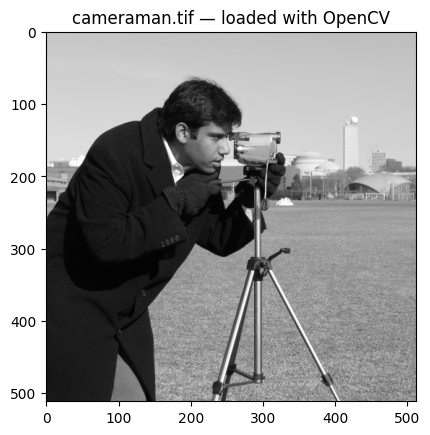

In [4]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('images/cameraman.tif')  # Load the image data into a NumPy array


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('cameraman.tif — loaded with OpenCV')
plt.show()

### 2b — Loading/reading an image using PIL

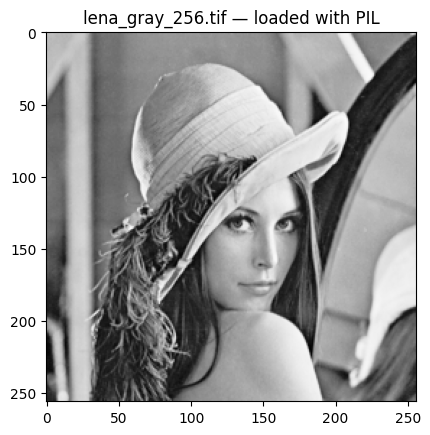

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

img2 = Image.open('images/lena_gray_256.tif')

plt.imshow(img2, cmap=cm.Greys_r)
plt.title('lena_gray_256.tif — loaded with PIL')
plt.show()

## Task #3: Image Storing

### 3a — Saving image to disk using OpenCV

In [6]:
cv2.imwrite('new_image.jpg', img)
print(f"Saved 'new_image.jpg' — size: {os.path.getsize('new_image.jpg'):,} bytes")

Saved 'new_image.jpg' — size: 86,612 bytes


### 3b — Saving image to disk using PIL

In [7]:
img2.save('new_image2.jpg')
print(f"Saved 'new_image2.jpg' — size: {os.path.getsize('new_image2.jpg'):,} bytes")

Saved 'new_image2.jpg' — size: 10,243 bytes


## Task #4: Display Image as an Array

### 4a — OpenCV image (already a NumPy array)

In [8]:
print("Shape of img (OpenCV):", img.shape)
print("Data type:", img.dtype)
print()
print(img)

Shape of img (OpenCV): (512, 512, 3)
Data type: uint8

[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


### 4b — PIL image → converted to NumPy array

In [9]:
import numpy as np

img_array = np.array(img2)

print("Shape of img_array (PIL → NumPy):", img_array.shape)
print("Data type:", img_array.dtype)
print()
print(img_array)

Shape of img_array (PIL → NumPy): (256, 256)
Data type: uint8

[[162 162 160 ... 170 170 143]
 [162 162 160 ... 171 172 146]
 [163 160 160 ... 159 149 116]
 ...
 [ 51  51  52 ...  82  93  92]
 [ 46  49  50 ...  93 101  99]
 [ 45  53  50 ... 100 103 106]]


## Section 4 — Assessment: NumPy Array Operations

In [10]:
print("=== cameraman (OpenCV) ===")
print(f"  Shape      : {img.shape}")
print(f"  Dimensions : {img.ndim}")
print(f"  Size       : {img.size} pixels")
print(f"  Dtype      : {img.dtype}")
print(f"  Min / Max  : {img.min()} / {img.max()}")
print()
print("=== lena_gray_256 (PIL → NumPy) ===")
print(f"  Shape      : {img_array.shape}")
print(f"  Dimensions : {img_array.ndim}")
print(f"  Size       : {img_array.size} pixels")
print(f"  Dtype      : {img_array.dtype}")
print(f"  Min / Max  : {img_array.min()} / {img_array.max()}")

=== cameraman (OpenCV) ===
  Shape      : (512, 512, 3)
  Dimensions : 3
  Size       : 786432 pixels
  Dtype      : uint8
  Min / Max  : 0 / 255

=== lena_gray_256 (PIL → NumPy) ===
  Shape      : (256, 256)
  Dimensions : 2
  Size       : 65536 pixels
  Dtype      : uint8
  Min / Max  : 23 / 240


ROI shape: (150, 150)


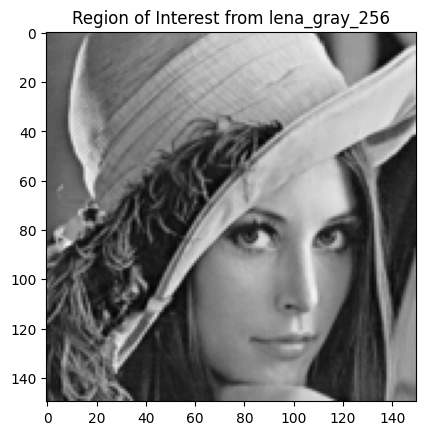

In [11]:
roi = img_array[50:200, 50:200]   # rows 50-199, cols 50-199
print(f"ROI shape: {roi.shape}")

plt.imshow(roi, cmap='gray')
plt.title('Region of Interest from lena_gray_256')
plt.show()

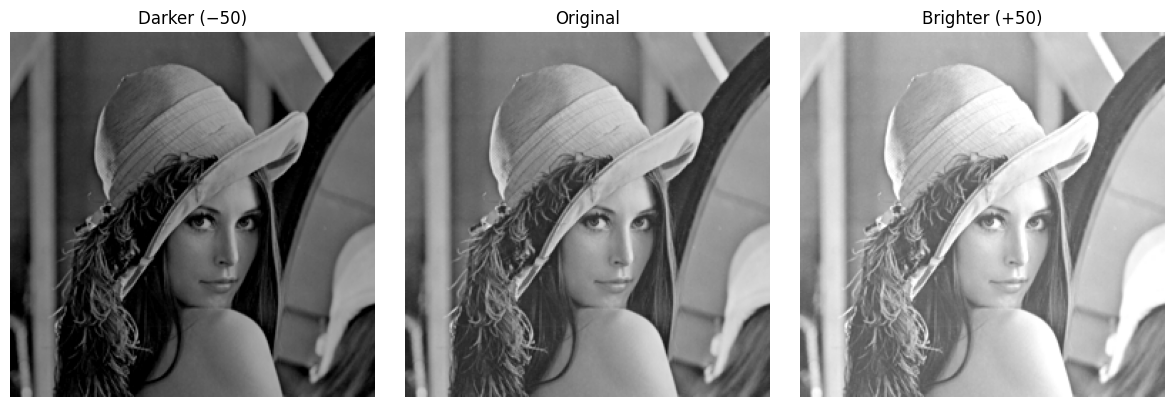

In [12]:
# ── Arithmetic: brightness adjustment ──
brighter = np.clip(img_array.astype(np.int16) + 50, 0, 255).astype(np.uint8)
darker   = np.clip(img_array.astype(np.int16) - 50, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, data, title in zip(axes,
                           [darker, img_array, brighter],
                           ['Darker (−50)', 'Original', 'Brighter (+50)']):
    ax.imshow(data, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

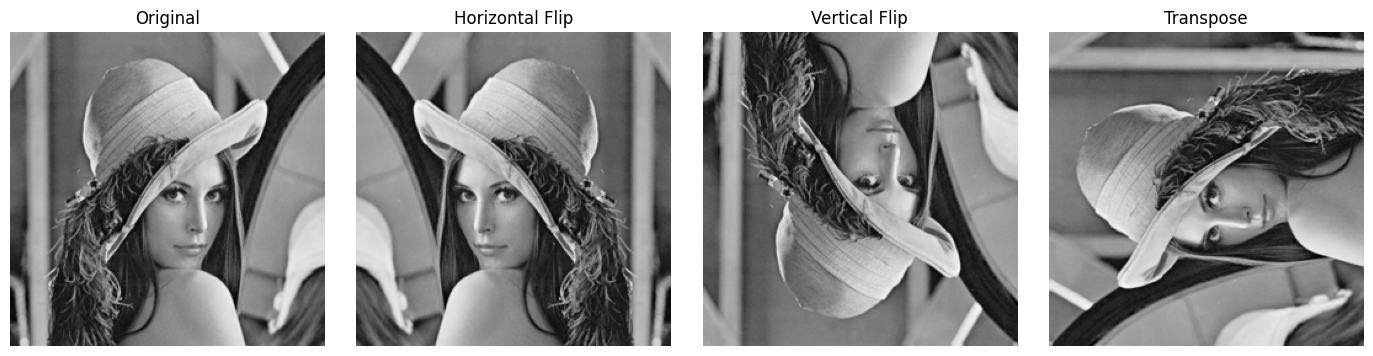

In [13]:
#  Flipping & transposing
flipped_h = np.fliplr(img_array)    # horizontal flip
flipped_v = np.flipud(img_array)    # vertical flip
transposed = img_array.T            # transpose

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, data, title in zip(axes,
                           [img_array, flipped_h, flipped_v, transposed],
                           ['Original', 'Horizontal Flip', 'Vertical Flip', 'Transpose']):
    ax.imshow(data, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
#Statistical summary
print(f"Mean pixel value : {img_array.mean():.2f}")
print(f"Std deviation    : {img_array.std():.2f}")
print(f"Median           : {np.median(img_array):.1f}")

Mean pixel value : 124.05
Std deviation    : 47.45
Median           : 129.0
